
Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message in geom_density_ridges(aes(fill = Method, color = Method), alpha = ridge_alpha, :
“Ignoring unknown parameters: `size`”
Picking joint bandwidth of 0.0247

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_density_ridges()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Picking joint bandwidth of 0.0247

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_density_ridges()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Picking joint bandwidth of 0.0247

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_density_ridges()`).”
Warning message:
“

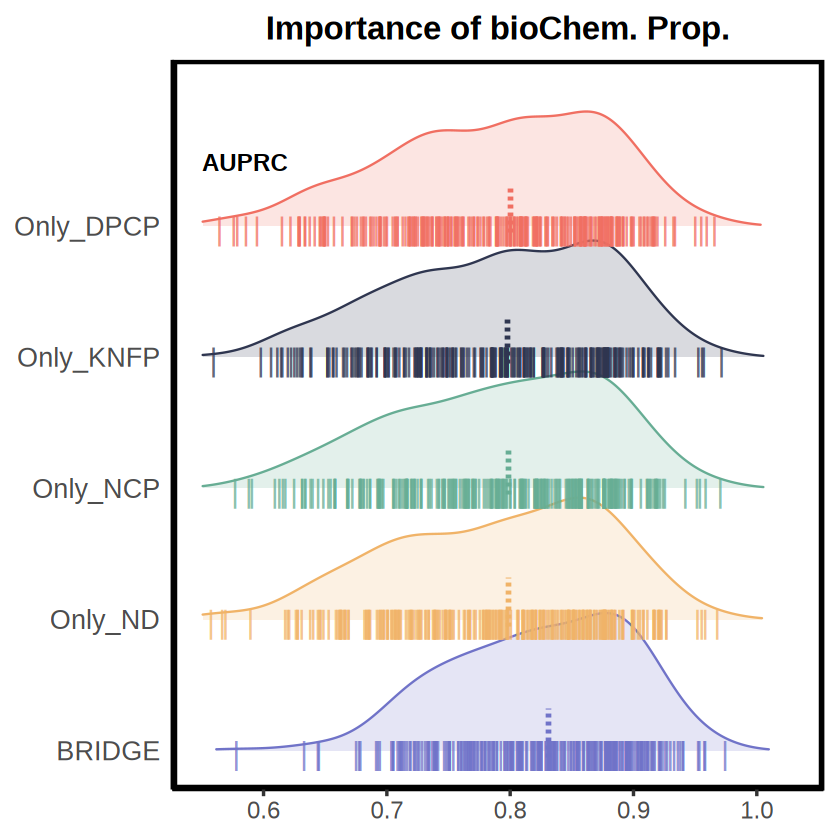

In [ ]:
# -------------------- packages --------------------
library(readxl)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggridges)

# -------------------- helper: clean names --------------------
clean_name <- function(x) {
  x <- gsub("\u00A0", " ", x)   # Convert NBSP to normal space
  x <- trimws(x)               # Remove leading/trailing whitespace
  x
}

# -------------------- main plotting function --------------------
plot_mountain_e <- function(
  xlsx_path,
  metric_label = "AUPRC",                    # Panel label at top-left (e.g., "AUPRC" / "AUPRC")
  title_text   = "Importance of bioChem. Prop.",
  out_pdf      = "mountain_AUPRC.pdf",
  out_png      = "mountain_AUPRC.png",
  xlim         = c(0.55, 1.03),
  xbreaks      = seq(0.6, 1.0, 0.1),
  ridge_scale  = 1.05,                     # Ridge height scaling factor
  ridge_alpha  = 0.18,                     # Ridge fill transparency
  ridge_lwd    = 1.0,                      # Ridge outline linewidth
  rug_offset   = 0.06,                     # Smaller value moves rug ticks upward (closer to ridges)
  rug_size     = 6,                        # Rug tick size
  rug_alpha    = 0.75,                     # Rug tick transparency
  dash_y0      = -0.05,                    # Dashed-line start offset relative to ridge baseline
  dash_y1      =  0.32,                    # Dashed-line end offset relative to ridge baseline
  stat_fun     = median,                   # Summary statistic for dashed line (median or mean)
  sheet        = NULL                      # Optional: Excel sheet name or index
) {
  # ---- desired order (top -> bottom) ----
  order_top_to_bottom <- c("Only_DPCP","Only_KNFP","Only_NCP","Only_ND","BRIDGE")
  order_top_to_bottom <- clean_name(order_top_to_bottom)

  # ---- read excel ----
  raw <- read_excel(xlsx_path, sheet = sheet)
  names(raw) <- clean_name(names(raw))

  # ---- check available columns ----
  present <- intersect(order_top_to_bottom, names(raw))
  missing <- setdiff(order_top_to_bottom, names(raw))
  if (length(missing) > 0) {
    message("   These columns are missing in the Excel file and will be skipped: ",
            paste(missing, collapse = ", "))
    message("   Excel columns detected: ", paste(names(raw), collapse = ", "))
  }
  if (length(present) == 0) stop("No expected columns found in the Excel file.")

  # ---- colors: MUST match Method names exactly ----
  cols_all <- c(
    "Only_DPCP" = "#f06f62",
    "Only_KNFP" = "#2f3650",
    "Only_NCP"  = "#67ad94",
    "Only_ND"   = "#f0b368",
    "BRIDGE"    = "#7073c8"
  )
  cols_all <- cols_all[clean_name(names(cols_all))]
  cols <- cols_all[present]  # Keep only columns that exist in the file

  # ---- wide -> long ----
  df <- raw %>%
    select(all_of(present)) %>%
    pivot_longer(cols = everything(), names_to = "Method", values_to = "value") %>%
    mutate(
      Method = clean_name(Method),
      value  = suppressWarnings(as.numeric(value))
    ) %>%
    filter(!is.na(value))

  # ---- set y order (bottom -> top) for numeric y ----
  levels_bottom_to_top <- rev(present)
  df <- df %>%
    mutate(
      Method = factor(Method, levels = levels_bottom_to_top),
      y      = as.numeric(Method)
    )

  # ---- per-group statistic for dashed line ----
  stat_df <- df %>%
    group_by(Method, y) %>%
    summarise(mid = stat_fun(value), .groups = "drop")

  # ---- rug positions (move UP by decreasing rug_offset) ----
  rug_df <- df %>%
    mutate(y_rug = y - rug_offset)

  # ---- build plot ----
  p <- ggplot(df, aes(x = value, y = y, group = Method)) +
    geom_density_ridges(
      aes(fill = Method, color = Method),
      alpha = ridge_alpha,
      size  = ridge_lwd,
      scale = ridge_scale,
      rel_min_height = 0.01
    ) +
    geom_point(
      data = rug_df,
      aes(x = value, y = y_rug, color = Method),
      inherit.aes = FALSE,
      shape = "|",
      size  = rug_size,
      alpha = rug_alpha
    ) +
    geom_segment(
      data = stat_df,
      aes(x = mid, xend = mid, y = y + dash_y0, yend = y + dash_y1, color = Method),
      inherit.aes = FALSE,
      linetype = "dashed",
      linewidth = 1.2
    ) +
    scale_fill_manual(values = cols, drop = FALSE) +
    scale_color_manual(values = cols, drop = FALSE) +
    scale_y_continuous(
      breaks = seq_along(levels_bottom_to_top),
      labels = levels_bottom_to_top,
      expand = expansion(mult = c(0.05, 0.08))
    ) +
    scale_x_continuous(breaks = xbreaks, limits = xlim) +
    labs(title = title_text, x = NULL, y = NULL) +
    annotate(
      "text",
      x = xlim[1], y = max(df$y) + 0.55,
      label = metric_label,
      hjust = 0, vjust = 1,
      fontface = "bold", size = 5
    ) +
    theme_classic(base_size = 16) +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5, face = "bold"),
      axis.text.y = element_text(size = 16),
      axis.text.x = element_text(size = 14),
      axis.ticks.y = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 2),
      plot.margin = margin(10, 10, 10, 10)
    )

  print(p)

  # ---- save ----
  # cairo_pdf is usually more reliable on Linux (fonts/transparency)
  ggsave(out_pdf, p, width = 6.5, height = 6.5, device = cairo_pdf)
  ggsave(out_png, p, width = 6.5, height = 6.5, dpi = 300)

  invisible(p)
}

# -------------------- run --------------------
xlsx_path <- "../ablation&interpretability/mountain_AUPRC.xlsx"

plot_mountain_e(
  xlsx_path    = xlsx_path,
  metric_label = "AUPRC",
  out_pdf      = "fig4e_AUPRC.pdf",
  out_png      = "fig4e_AUPRC.png",
  rug_offset   = 0.04   # Set smaller to move rug ticks upward; larger to move them downward
)
